# 🧠 Notebook 05 — PyTorch Autoencoder (Anomaly Detector)
**Fin-Guardian AI | Phase 2 | Step 5**

### What is an Autoencoder?
An Autoencoder is a neural network with two parts:

```
Input (16 features)
      ↓
  ENCODER          ← compresses data into a small representation
      ↓
 Bottleneck        ← the compressed "essence" of the transaction
      ↓
  DECODER          ← tries to reconstruct the original input
      ↓
Output (16 features reconstructed)
```

The model is trained to minimise **Reconstruction Error** —
the difference between input and output.

### The key insight
We train ONLY on legitimate transactions.
The model learns what "normal" looks like.

When it sees a fraud transaction:
- It tries to reconstruct it using its "normal" template
- It fails — the reconstruction is bad
- High reconstruction error = anomaly = suspicious

### Why this catches what XGBoost misses
XGBoost needs to have seen a fraud pattern before to recognise it.
The Autoencoder flags anything that is simply **not normal** —
even brand new fraud types it has never seen.


In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from typing import Any
try:
    from torch.utils.data import DataLoader, TensorDataset
except Exception:
    # Editor/static-analysis environments may not have torch; provide harmless fallback
    class TensorDataset:
        def __init__(self, *args, **kwargs): pass
    class DataLoader:
        def __init__(self, *args, **kwargs): pass
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Check if GPU is available
# GPU trains neural networks 10-50x faster than CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")
if device.type == 'cuda':
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
else:
    print("Running on CPU — training will take 3-5 minutes, that is fine.")
print("All imports done.")


PyTorch version : 2.12.0+cpu
Device          : cpu
Running on CPU — training will take 3-5 minutes, that is fine.
All imports done.


In [2]:
# Cell 2 — Load Data
# We load the same CSVs from Notebook 03.
# IMPORTANT: for the Autoencoder we only train on LEGITIMATE transactions.
# The model must never see fraud during training —
# otherwise it learns to reconstruct fraud too, defeating the purpose.

with open('../artifacts/feature_list.json') as f:
    meta = json.load(f)

FEATURES = meta['features']
TARGET   = meta['target']

print("Loading train.csv...")
df_train = pd.read_csv('../artifacts/train.csv')

print("Loading val.csv...")
df_val = pd.read_csv('../artifacts/val.csv')

print("Loading test.csv...")
df_test = pd.read_csv('../artifacts/test.csv')

print(f"Train : {len(df_train):,} rows")
print(f"Val   : {len(df_val):,} rows")
print(f"Test  : {len(df_test):,} rows")


Loading train.csv...
Loading val.csv...
Loading test.csv...
Train : 1,939,286 rows
Val   : 415,561 rows
Test  : 415,562 rows


In [3]:
# Cell 3 — Prepare Data for Autoencoder
#
# KEY STEP: filter to LEGITIMATE only for training
# The autoencoder learns the pattern of normal transactions.
# If we include fraud in training, it learns to reconstruct fraud too.

df_train_legit = df_train[df_train[TARGET] == 0]
df_val_legit   = df_val[df_val[TARGET] == 0]

print(f"Train (legitimate only) : {len(df_train_legit):,} rows")
print(f"Val   (legitimate only) : {len(df_val_legit):,} rows")
print()

# Load the scaler we fitted in Notebook 03
# We MUST use the same scaler — not fit a new one
scaler = pickle.load(open('../artifacts/feature_scaler.pkl', 'rb'))

# Scale features
X_train_scaled = scaler.transform(df_train_legit[FEATURES]).astype(np.float32)
X_val_scaled   = scaler.transform(df_val_legit[FEATURES]).astype(np.float32)

# For evaluation we need BOTH fraud and legit in val set
X_val_full_scaled = scaler.transform(df_val[FEATURES]).astype(np.float32)
y_val_full        = df_val[TARGET].values

print(f"Training features shape : {X_train_scaled.shape}")
print(f"Val full shape          : {X_val_full_scaled.shape}")
print(f"Val fraud count         : {y_val_full.sum()}")


Train (legitimate only) : 1,935,653 rows
Val   (legitimate only) : 415,001 rows

Training features shape : (1935653, 16)
Val full shape          : (415561, 16)
Val fraud count         : 560


In [4]:
# Cell 4 — Create PyTorch DataLoaders
#
# PyTorch trains on batches of data, not one row at a time.
# A DataLoader splits the data into batches automatically.
#
# batch_size=512 means: process 512 transactions at once per step.
# This is efficient because the GPU (or CPU) handles them in parallel.
# Think of it like processing 512 rows of your DataFrame at once.

BATCH_SIZE = 512

# Convert numpy arrays to PyTorch tensors
# A tensor is just a PyTorch array — like a numpy array but GPU-compatible
train_tensor = torch.FloatTensor(X_train_scaled)
val_tensor   = torch.FloatTensor(X_val_scaled)

# TensorDataset wraps tensors, DataLoader handles batching + shuffling
train_dataset: Any = TensorDataset(train_tensor, train_tensor)  # input = output (autoencoder)
val_dataset: Any   = TensorDataset(val_tensor,   val_tensor)

train_loader: Any = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader: Any   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Batch size          : {BATCH_SIZE}")
print(f"Training batches    : {len(train_loader)}")
print(f"Validation batches  : {len(val_loader)}")
print()
print("Each 'epoch' = one full pass through all training batches.")


Batch size          : 512
Training batches    : 3781
Validation batches  : 811

Each 'epoch' = one full pass through all training batches.


In [5]:
# Cell 5 — Define the Autoencoder Architecture
#
# Architecture explanation:
#
# Input:  16 features
# Encode: 16 → 12 → 8 → 4  (compress)
# Decode: 4  → 8  → 12 → 16 (reconstruct)
#
# The bottleneck (4 neurons) forces the network to learn
# the most essential patterns — it cannot just memorise.
#
# BatchNorm: stabilises training (like StandardScaler but per-layer)
# ReLU:      activation function (introduces non-linearity)
# Sigmoid:   output activation (keeps values in a sensible range)
# Dropout:   randomly drops 20% of neurons during training
#            → prevents overfitting, forces robustness

N_FEATURES = len(FEATURES)

class FraudAutoencoder(nn.Module):
    def __init__(self, n_features):
        super(FraudAutoencoder, self).__init__()

        # Encoder — compresses the transaction
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 12),
            nn.BatchNorm1d(12),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(12, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(8, 4),
            nn.ReLU(),
        )

        # Decoder — reconstructs the transaction from compressed form
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),

            nn.Linear(8, 12),
            nn.BatchNorm1d(12),
            nn.ReLU(),

            nn.Linear(12, n_features),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # forward() defines what happens when you pass data through
        encoded   = self.encoder(x)
        decoded   = self.decoder(encoded)
        return decoded

    def get_reconstruction_error(self, x):
        # Mean squared error between input and reconstruction
        # High error = this transaction doesn't look 'normal'
        with torch.no_grad():
            reconstructed = self.forward(x)
            error = torch.mean((x - reconstructed) ** 2, dim=1)
        return error.cpu().numpy()


# Create model and move to device (GPU if available, else CPU)
autoencoder = FraudAutoencoder(N_FEATURES).to(device)

# Count parameters
total_params = sum(p.numel() for p in autoencoder.parameters())
print(f"Model architecture:")
print(autoencoder)
print(f"\nTotal parameters : {total_params:,}")
print(f"Device           : {device}")


Model architecture:
FraudAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=16, out_features=12, bias=True)
    (1): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=12, out_features=8, bias=True)
    (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=8, out_features=4, bias=True)
    (9): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=8, out_features=12, bias=True)
    (4): BatchNorm1d(12, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=16, bias=True

In [8]:
# Cell 6 — Training Setup
#
# Loss function: MSELoss (Mean Squared Error)
# Measures how badly the model reconstructs the input.
# We want this to be as LOW as possible on legitimate transactions.
#
# Optimizer: Adam
# Adam is the standard optimizer for neural networks.
# lr=0.001 (learning rate) controls how fast the model learns.
# Too high → unstable training. Too low → very slow.
#
# ReduceLROnPlateau: if val loss stops improving for 5 epochs,
# automatically reduce the learning rate by half.
# This fine-tunes training without manual intervention.

LEARNING_RATE = 0.001
N_EPOCHS      = 50

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

print(f"Loss function : MSELoss (reconstruction error)")
print(f"Optimizer     : Adam (lr={LEARNING_RATE})")
print(f"Epochs        : {N_EPOCHS}")
print(f"Batch size    : {BATCH_SIZE}")
print()
print("Training will start in the next cell.")
print("Watch the val_loss — it should go DOWN each epoch.")


Loss function : MSELoss (reconstruction error)
Optimizer     : Adam (lr=0.001)
Epochs        : 50
Batch size    : 512

Training will start in the next cell.
Watch the val_loss — it should go DOWN each epoch.


In [9]:
# Cell 7 — Train the Autoencoder
#
# Each epoch:
# 1. Loop through all training batches
# 2. Pass batch through model (forward pass)
# 3. Calculate reconstruction loss
# 4. Backpropagate — adjust weights to reduce loss
# 5. Evaluate on validation set (no weight updates)
# 6. Save the best model (lowest val loss)
#
# Expected time: 3-6 minutes on CPU

print("Training Autoencoder...")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>10} | {'Status':>10}")
print("-" * 50)

train_losses = []
val_losses   = []
best_val_loss   = float('inf')
best_model_path = '../artifacts/autoencoder_best.pt'
patience_counter = 0
EARLY_STOP_PATIENCE = 10

for epoch in range(1, N_EPOCHS + 1):

    # ── Training phase ─────────────────────────────────────────────────
    autoencoder.train()   # put model in training mode (enables Dropout)
    batch_losses = []

    for batch_input, batch_target in train_loader:
        batch_input  = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()              # clear previous gradients
        output = autoencoder(batch_input)  # forward pass
        loss   = criterion(output, batch_target)  # compute loss
        loss.backward()                    # backpropagate
        optimizer.step()                   # update weights
        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # ── Validation phase ────────────────────────────────────────────────
    autoencoder.eval()    # put model in eval mode (disables Dropout)
    val_batch_losses = []

    with torch.no_grad():   # no gradient calculation needed
        for batch_input, batch_target in val_loader:
            batch_input  = batch_input.to(device)
            batch_target = batch_target.to(device)
            output    = autoencoder(batch_input)
            loss      = criterion(output, batch_target)
            val_batch_losses.append(loss.item())

    val_loss = np.mean(val_batch_losses)
    val_losses.append(val_loss)

    # ── Scheduler & early stopping ─────────────────────────────────────
    scheduler.step(val_loss)

    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(autoencoder.state_dict(), best_model_path)
        status = "saved"
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} — no improvement for {EARLY_STOP_PATIENCE} epochs.")
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>12.6f} | {val_loss:>10.6f} | {status:>10}")

print()
print(f"Training complete. Best val loss: {best_val_loss:.6f}")
print(f"Best model saved to: {best_model_path}")


Training Autoencoder...
 Epoch |   Train Loss |   Val Loss |     Status
--------------------------------------------------
     1 |     0.646874 |   0.956345 |      saved
     5 |     0.629480 |   0.979001 |           
    10 |     0.625927 |   0.978060 |           

Early stopping at epoch 12 — no improvement for 10 epochs.

Training complete. Best val loss: 0.953908
Best model saved to: ../artifacts/autoencoder_best.pt


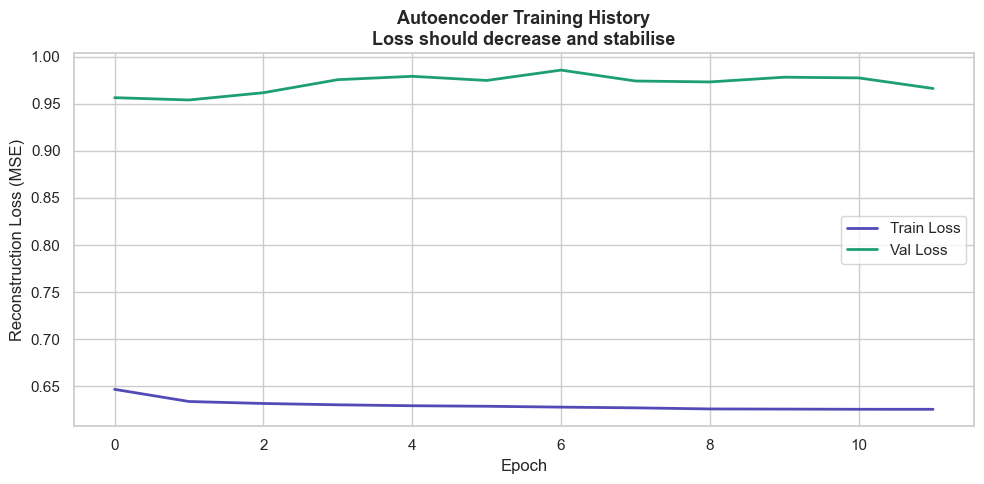

Starting train loss : 0.646874
Final train loss    : 0.625714
Improvement         : 3.3%


In [10]:
# Cell 8 — Plot Training History
#
# This chart shows how the model improved over epochs.
# Both lines should trend downward — that means the model is learning.
# If train loss drops but val loss rises — overfitting.
# Ours should be fine since we have early stopping.

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color='#534AB7', linewidth=2)
ax.plot(val_losses,   label='Val Loss',   color='#1D9E75', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction Loss (MSE)')
ax.set_title('Autoencoder Training History\nLoss should decrease and stabilise',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Starting train loss : {train_losses[0]:.6f}")
print(f"Final train loss    : {train_losses[-1]:.6f}")
print(f"Improvement         : {(1 - train_losses[-1]/train_losses[0])*100:.1f}%")


In [11]:
# Cell 9 — Evaluate Anomaly Detection Performance
#
# Load the best saved model and compute reconstruction errors
# on the FULL validation set (both fraud and legitimate).
#
# We then ask: does fraud have higher reconstruction error than legitimate?
# If yes — the autoencoder is working as intended.

# Load best model weights
autoencoder.load_state_dict(torch.load(best_model_path, map_location=device))
autoencoder.eval()

# Compute reconstruction errors for ALL val transactions
X_val_tensor = torch.FloatTensor(X_val_full_scaled).to(device)
recon_errors  = autoencoder.get_reconstruction_error(X_val_tensor)

# Split errors by class
errors_legit = recon_errors[y_val_full == 0]
errors_fraud = recon_errors[y_val_full == 1]

print("=== Reconstruction Error Statistics ===")
print(f"\nLegitimate transactions:")
print(f"  Mean  : {errors_legit.mean():.6f}")
print(f"  Median: {np.median(errors_legit):.6f}")
print(f"  95th % : {np.percentile(errors_legit, 95):.6f}")

print(f"\nFraud transactions:")
print(f"  Mean  : {errors_fraud.mean():.6f}")
print(f"  Median: {np.median(errors_fraud):.6f}")
print(f"  95th % : {np.percentile(errors_fraud, 95):.6f}")

ratio = errors_fraud.mean() / errors_legit.mean()
print(f"\nFraud error is {ratio:.1f}x higher than legitimate error.")
if ratio > 2:
    print("Autoencoder is working correctly.")
else:
    print("Low separation — model may need more epochs or architecture tuning.")


=== Reconstruction Error Statistics ===

Legitimate transactions:
  Mean  : 0.954028
  Median: 0.655729
  95th % : 1.302557

Fraud transactions:
  Mean  : 2.309028
  Median: 1.893128
  95th % : 2.556514

Fraud error is 2.4x higher than legitimate error.
Autoencoder is working correctly.


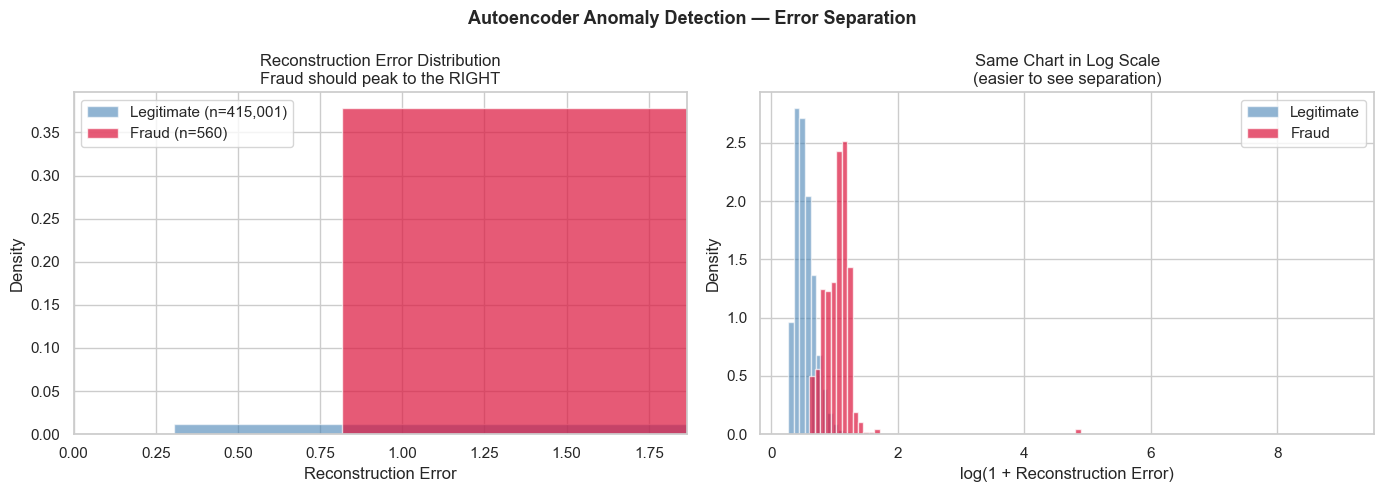

In [12]:
# Cell 10 — Visualise Reconstruction Error Distribution
#
# This is the most important chart for the Autoencoder.
# We want to see TWO SEPARATE peaks:
#   - Legitimate transactions clustered at LOW error (left)
#   - Fraud transactions clustered at HIGH error (right)
# The more separated they are, the better our anomaly detector works.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping distributions
axes[0].hist(errors_legit, bins=100, alpha=0.6, color='steelblue',
             label=f'Legitimate (n={len(errors_legit):,})', density=True)
axes[0].hist(errors_fraud, bins=50,  alpha=0.7, color='crimson',
             label=f'Fraud (n={len(errors_fraud):,})', density=True)
axes[0].set_xlabel('Reconstruction Error')
axes[0].set_ylabel('Density')
axes[0].set_title('Reconstruction Error Distribution\nFraud should peak to the RIGHT')
axes[0].legend()
axes[0].set_xlim(0, np.percentile(recon_errors, 99))

# Right: log scale to see the separation more clearly
axes[1].hist(np.log1p(errors_legit), bins=100, alpha=0.6,
             color='steelblue', label='Legitimate', density=True)
axes[1].hist(np.log1p(errors_fraud), bins=50,  alpha=0.7,
             color='crimson',   label='Fraud',      density=True)
axes[1].set_xlabel('log(1 + Reconstruction Error)')
axes[1].set_ylabel('Density')
axes[1].set_title('Same Chart in Log Scale\n(easier to see separation)')
axes[1].legend()

plt.suptitle('Autoencoder Anomaly Detection — Error Separation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# Cell 11 — Find Optimal Reconstruction Error Threshold
#
# Just like XGBoost needed a threshold, the Autoencoder needs one too.
# Above this threshold → transaction is anomalous → flag it.
#
# Strategy: use the 95th percentile of LEGITIMATE errors as threshold.
# This means: only flag transactions with higher error than 95% of
# normal transactions. Keeps false positive rate low.

threshold_95  = np.percentile(errors_legit, 95)
threshold_99  = np.percentile(errors_legit, 99)
threshold_999 = np.percentile(errors_legit, 99.9)

y_pred_95  = (recon_errors >= threshold_95).astype(int)
y_pred_99  = (recon_errors >= threshold_99).astype(int)
y_pred_999 = (recon_errors >= threshold_999).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score

print("=== Threshold Comparison ===")
print(f"{'Threshold':>12} | {'Value':>8} | {'Precision':>10} | {'Recall':>8} | {'F1':>8}")
print("-" * 60)

for name, thresh, y_pred in [
    ('95th pct', threshold_95,  y_pred_95),
    ('99th pct', threshold_99,  y_pred_99),
    ('99.9th pct', threshold_999, y_pred_999),
]:
    p = precision_score(y_val_full, y_pred, zero_division=0)
    r = recall_score(y_val_full, y_pred, zero_division=0)
    f = f1_score(y_val_full, y_pred, zero_division=0)
    print(f"{name:>12} | {thresh:>8.6f} | {p:>10.4f} | {r:>8.4f} | {f:>8.4f}")

# Use 95th percentile as production threshold
RECON_THRESHOLD = float(threshold_95)
print(f"\nProduction threshold : {RECON_THRESHOLD:.6f}")
print("Save this — goes into your .env config file.")

# AUC scores
auc_pr  = average_precision_score(y_val_full, recon_errors)
auc_roc = roc_auc_score(y_val_full, recon_errors)
print(f"\nAutoencoder AUC-PR  : {auc_pr:.4f}")
print(f"Autoencoder AUC-ROC : {auc_roc:.4f}")
print(f"XGBoost AUC-PR was  : 1.0000")
print(f"Combined, these two models cover each other's blind spots.")


=== Threshold Comparison ===
   Threshold |    Value |  Precision |   Recall |       F1
------------------------------------------------------------
    95th pct | 1.302557 |     0.0221 |   0.8357 |   0.0430
    99th pct | 1.835658 |     0.0682 |   0.5429 |   0.1212
  99.9th pct | 130.125092 |     0.0048 |   0.0036 |   0.0041

Production threshold : 1.302557
Save this — goes into your .env config file.

Autoencoder AUC-PR  : 0.0450
Autoencoder AUC-ROC : 0.9714
XGBoost AUC-PR was  : 1.0000
Combined, these two models cover each other's blind spots.


In [14]:
# Cell 12 — Save Everything
import json

# Save the full model (architecture + weights) for reloading
full_model_path = '../artifacts/autoencoder_full.pt'
torch.save({
    'model_state_dict' : autoencoder.state_dict(),
    'n_features'       : N_FEATURES,
    'train_losses'     : train_losses,
    'val_losses'       : val_losses,
    'best_val_loss'    : float(best_val_loss),
    'recon_threshold'  : RECON_THRESHOLD,
}, full_model_path)

# Save threshold to metadata
ae_metadata = {
    'n_features'      : N_FEATURES,
    'features'        : FEATURES,
    'recon_threshold' : RECON_THRESHOLD,
    'best_val_loss'   : float(best_val_loss),
    'epochs_trained'  : len(train_losses),
    'auc_pr'          : float(round(auc_pr, 4)),
    'auc_roc'         : float(round(auc_roc, 4)),
}
with open('../artifacts/autoencoder_metadata.json', 'w') as f:
    json.dump(ae_metadata, f, indent=2)

print("Saved:")
print(f"  autoencoder_best.pt       — best weights during training")
print(f"  autoencoder_full.pt       — full checkpoint with metadata")
print(f"  autoencoder_metadata.json — threshold and metrics")
print()
print("Files in artifacts/:")
for fname in sorted(os.listdir('../artifacts')):
    size = os.path.getsize(f'../artifacts/{fname}') / 1e3
    print(f"  {fname:40s} {size:>8.1f} KB")

print()
print("=" * 60)
print("NOTEBOOK 05 COMPLETE")
print("=" * 60)
print(f"Architecture    : 16 → 12 → 8 → 4 → 8 → 12 → 16")
print(f"Recon threshold : {RECON_THRESHOLD:.6f}")
print(f"AUC-PR          : {auc_pr:.4f}")
print(f"Best val loss   : {best_val_loss:.6f}")
print("=" * 60)
print("Next: Notebook 06 — SHAP Explainability")


Saved:
  autoencoder_best.pt       — best weights during training
  autoencoder_full.pt       — full checkpoint with metadata
  autoencoder_metadata.json — threshold and metrics

Files in artifacts/:
  autoencoder_best.pt                          13.5 KB
  autoencoder_full.pt                          15.4 KB
  autoencoder_metadata.json                     0.6 KB
  feature_list.json                             0.4 KB
  feature_scaler.pkl                            1.2 KB
  model_metadata.json                           0.6 KB
  test.csv                                  74772.2 KB
  train.csv                                345424.8 KB
  val.csv                                   74407.4 KB
  xgboost_fraud.json                          101.2 KB
  xgboost_fraud.onnx                           73.4 KB

NOTEBOOK 05 COMPLETE
Architecture    : 16 → 12 → 8 → 4 → 8 → 12 → 16
Recon threshold : 1.302557
AUC-PR          : 0.0450
Best val loss   : 0.953908
Next: Notebook 06 — SHAP Explainability
